# Exercise B.1.1: Design Principles in the Wild
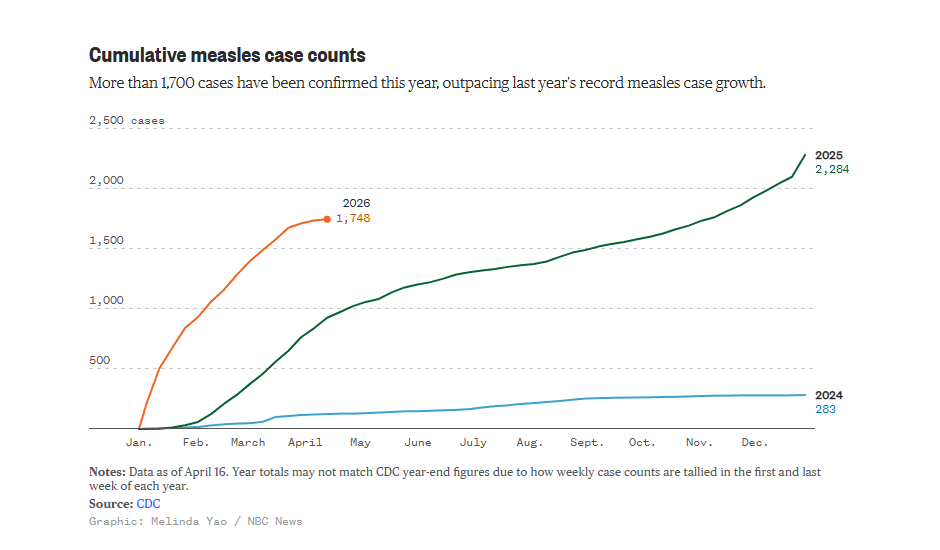

1. The chart used in the visualization above is a line chart.
2. Yes it follows the golden rule of axes starting from 0, and the colors intentionally distinguish each year.
3. The audience intended is the american public and it is trying to show that in measles cases is growing faster than the previous years record     measles case growth
4. I would show the projected growth for the remainder of the year at its current pace. I would also make the lines for 2025 and 2024 less prominent so that the current years line stands out more because I feel, the line for 2025 competes with 2026 visually.

# Exercise B.1.2: Three-Act Storytelling
Task: Take a dataset or finding you have (10 mins)

Structure it as a story:
* Act 1 (Context): What's the business/research context?
* Act 2 (Problem/Opportunity): What does your analysis reveal?
* Act 3 (Action): What should someone do with this insight?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
# A random example dataset from Kaggle
data = pd.read_csv('imdb_top_1000.csv', index_col=False)

# I want Released_Year, IMDB_Rating to show the average IMDB_Rating over the decades to know if the trend of the ratings of movies
data = data[['Series_Title', 'Released_Year', 'IMDB_Rating']]

# 1 of the data entries has wrong data type for the year, so i am dropping it as it accounts for 0.1% of the dataset only
data['Released_Year'] = pd.to_numeric(data['Released_Year'], errors='coerce')
data = data.dropna(subset=['Released_Year'])
data['Released_Year'] = data['Released_Year'].astype(int)

data['Decade'] = (data['Released_Year'] // 10) * 10
data

,Series_Title,Released_Year,IMDB_Rating,Decade
0,The Shawshank Redemption,1994,9.3,1990
1,The Godfather,1972,9.2,1970
2,The Dark Knight,2008,9.0,2000
3,The Godfather: Part II,1974,9.0,1970
4,12 Angry Men,1957,9.0,1950
...,...,...,...,...
995,Breakfast at Tiffany's,1961,7.6,1960
996,Giant,1956,7.6,1950
997,From Here to Eternity,1953,7.6,1950
998,Lifeboat,1944,7.6,1940


In [61]:
print("----- Missing Information ----- ")
print(data.isna().sum())

print("\n----- Data Info -----")
print(data.info())

print("\n----- Summary Stats -----")
print(data.describe())

----- Missing Information ----- 
Series_Title     0
Released_Year    0
IMDB_Rating      0
dtype: int64

----- Data Info -----
<class 'pandas.core.frame.DataFrame'>
Int64Index: 999 entries, 0 to 999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   999 non-null    object 
 1   Released_Year  999 non-null    int32  
 2   IMDB_Rating    999 non-null    float64
dtypes: float64(1), int32(1), object(1)
memory usage: 27.3+ KB
None

----- Summary Stats -----
       Released_Year  IMDB_Rating
count     999.000000   999.000000
mean     1991.217217     7.949650
std        23.297025     0.275407
min      1920.000000     7.600000
25%      1976.000000     7.700000
50%      1999.000000     7.900000
75%      2009.000000     8.100000
max      2020.000000     9.300000


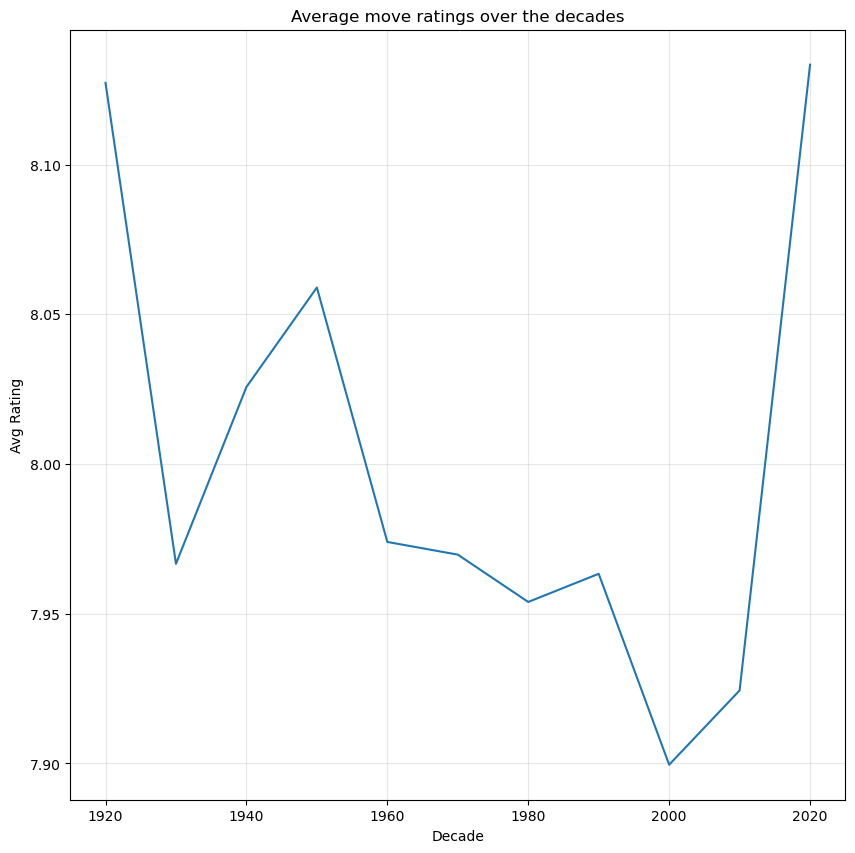

In [64]:
fig, axes = plt.subplots(1, 1, figsize=(10, 10))

sns.lineplot(data=data, x='Decade', y='IMDB_Rating', ax=axes, errorbar=None)
axes.set_title('Average move ratings over the decades')
axes.set_xlabel('Decade')
axes.set_ylabel('Avg Rating')
axes.grid(True, alpha=0.3)

